In [56]:
import torch
from torch import nn
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib import cm

In [57]:
# Define a simple neural network for regression
class simple_NN(nn.Module):
    def __init__(self):
        super(simple_NN, self).__init__()
        self.linear_tanh_stack = nn.Sequential(
            nn.Linear(1, 16),
            nn.Tanh(),
            nn.Linear(16, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        out = self.linear_tanh_stack(x)
        return out

# Start with initial condition

$ f(t_0) = 0.1$ 

$R = 1 $

In [58]:
ft0 = 0.1
R=1

In [59]:
x_train = torch.tensor([
    [0.0000],
    [0.1500],
    [0.3000],
    [0.4500],
    [0.7500]
])

y_train = torch.tensor([
    [0.1000],
    [0.1140],
    [0.1304],
    [0.1484],
    [0.1909]
])

In [60]:
def df(f:simple_NN, x: torch.Tensor = None, order: int = 1) -> torch.Tensor:
    df_value = f(x)
    for _ in range(order):
        df_value = torch.autograd.grad(
            df_value,
            x,
            grad_outputs=torch.ones_like(x),
            create_graph=True,
            retain_graph=True
        )[0]
    return df_value

Afte that we calculate $L_{PDE}$

In [105]:
domain = [0.0, 1.5]
t = torch.linspace(domain[0], domain[1], steps=20, requires_grad=True).reshape(-1,1)

In [106]:
def compute_loss(nn: simple_NN,
                 t: torch.Tensor = None,
                 x: torch.Tensor = None,
                 y: torch.Tensor = None
                 ) -> torch.float:
    pde_loss = df(nn,t) - R*nn(t)*(1-nn(t))
    pde_loss = pde_loss.pow(2).mean()

    boundary = torch.Tensor([0.0])
    boundary.requires_grad = True
    bc_loss = nn(boundary) - ft0
    bc_loss = bc_loss.pow(2)

    mse_loss = torch.nn.MSELoss()(nn(x), y)

    tot_loss = pde_loss + bc_loss + mse_loss

    return tot_loss


In [107]:
model = simple_NN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

#Train
for ep in range(500):

    loss = compute_loss(model, t, x_train, y_train)

    # BackPropagation

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if ep % 100 == 0:
        print(f"epoch: {ep}, loss: {loss.item():>7f}")


epoch: 0, loss: 0.035081
epoch: 100, loss: 0.000053
epoch: 200, loss: 0.000010
epoch: 300, loss: 0.000008
epoch: 400, loss: 0.000006


In [108]:
# # Initialize the model
# model = simple_NN()

# # define loss and optimizer
# loss_fn = nn.MSELoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

# # Train
# for ep in range(2000):

#     # Compute prediction error
#     pred = model(x_train)
#     loss = loss_fn(pred, y_train)

#     # Backpropagation
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()

#     if ep % 100 == 0:
#         print(f"epoch: {ep}, loss: {loss.item():>7f}")
# # evaluate the model on all data points in the domain
# domain = [0.0, 1.5]
# x_eval = torch.linspace(domain[0], domain[1], steps=100).reshape(-1, 1)
# f_eval = model(x_eval)

# # plotting
# fig, ax = plt.subplots(figsize=(15, 7))
# ax.scatter(x_train.detach().numpy(), y_train.detach().numpy(), label="Training data", color="blue")
# ax.plot(x_eval.detach().numpy(), f_eval.detach().numpy(), label="NN approximation", color="black")
# ax.set(title="Neural Network Regression", xlabel="x", ylabel="y")
# ax.legend()

In [109]:
# Численное решение логистического уравнения:
# df/dt = R * f * (1 - f)

def logistic_eq_fn(t, f):
    return R * f * (1 - f)


numeric_solution = solve_ivp(
    logistic_eq_fn,
    domain,
    [ft0],
    t_eval=x_eval.squeeze().detach().numpy()
)


f_colloc = solve_ivp(
    logistic_eq_fn,
    domain,
    [ft0],
    t_eval=t.squeeze().detach().numpy()
).y.T

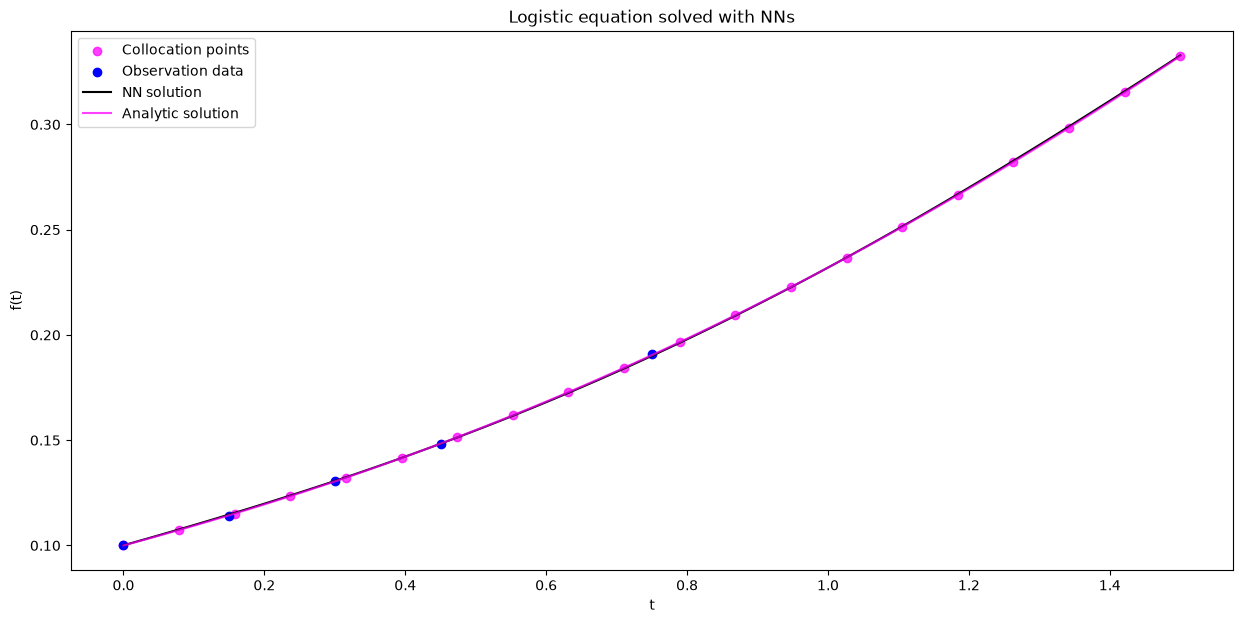

In [110]:
# plotting
fig, ax = plt.subplots(figsize=(15, 7))

f_eval = model(x_eval)

ax.scatter(t.detach().numpy(), f_colloc, label="Collocation points", color="magenta", alpha=0.75)
ax.scatter(x_train.detach().numpy(), y_train.detach().numpy(), label="Observation data", color="blue")
ax.plot(x_eval.detach().numpy(), f_eval.detach().numpy(), label="NN solution", color="black")
ax.plot(
    x_eval.detach().numpy(),
    numeric_solution.y.T,
    label="Analytic solution",
    color="magenta",
    alpha=0.75,
)
ax.set(title="Logistic equation solved with NNs", xlabel="t", ylabel="f(t)")
ax.legend()